In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from graphviz import Digraph

# TODO: Can we also apply BFS here? Is it related to backprop
def trace(root):
    """ Builds a set of all nodes and edges in a graph by applying depth-first search (DFS)"""
    nodes, edges = set(), set()
    
    def dfs(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._children:
                edges.add((child, v)) # Is it directed?
                dfs(child)
    
    dfs(root)
    return nodes, edges
    

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR: left to right

    def make_node_id(node, op=''):
        return str(id(node)) + op

    nodes, edges = trace(root)
    for v in nodes:
        uid = make_node_id(v)
        # For any value in the graph, create a rectangular (record) node for it
        dot.node(name=uid, label="{%s | data=%.4f | grad=%.4f}" % (v.label, v.data, v.grad), shape='record')
        if v._op:
            # If this value is a result of some operation, create an op node and connect it
            uid_op = make_node_id(v, v._op)
            dot.node(name=uid_op, label=v._op)
            dot.edge(uid_op, uid)
    
    for u, v in edges:
        # Connect nides with operations
        dot.edge(make_node_id(u), make_node_id(v, v._op))

    return dot


In [ ]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._children = set(_children)
        self._backward = lambda: None
        self._op = _op
        self.label = label
    
    def __repr__(self):
        return f"Value(data={self.data}, label={self.label})"
    
    def __add__(self, other):
        out = Value(self.data + other.data,  (self, other), '+')

        def _backward():
            self.grad = 1.0 * out.grad
            other.grad = 1.0 * out.grad

        out._backward = _backward
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')        

        def _backward():
            self.grad = other.data * out.grad
            other.grad = self.data * out.grad

        out._backward = _backward
        return out
    
    def tanh(self):
        # tanh = e**(2x) - 1 / e**(2x) + 1
        t = (math.exp(2*self.data) - 1) / (math.exp(2*self.data) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            # derivative of tanh is 1 - tanh(n)**2
            self.grad = 1 - t**2 * out.grad

        out._backward = _backward
        return out


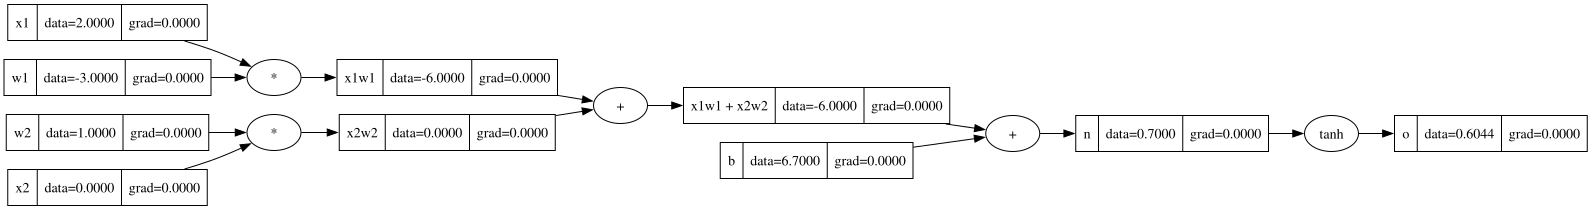

In [4]:
# Creating a small neural network
def network(x1, x2, w1, w2, b):
    # inputs
    x1 = Value(x1, label='x1')
    x2 = Value(x2, label='x2')
    # weights
    w1 = Value(w1, label='w1')
    w2 = Value(w2, label='w2')
    # bias
    b = Value(b, label='b')

    # network
    x1w1 = x1 * w1; x1w1.label = 'x1w1'
    x2w2 = x2 * w2; x2w2.label = 'x2w2'
    x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
    n = x1w1x2w2 + b; n.label = 'n'
    o = n.tanh(); o.label = 'o'
    return o


o = network(x1=2.0, x2=0.0, w1=-3.0, w2=1.0, b=6.7)
draw_dot(o)

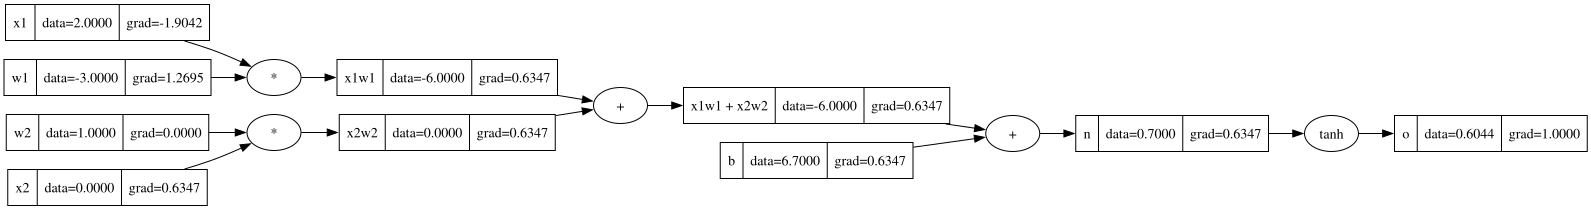

In [5]:
# inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias
b = Value(6.7, label='b')

# network
x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'


# Manually calculating the gradient
o.grad = 1.0
n.grad = 1.0 - o.data ** 2 # do/dn = 1 - tanh(n)**2
b.grad = 1.0 * n.grad
x1w1x2w2.grad = 1.0 * n.grad
x1w1.grad = 1.0 * x1w1x2w2.grad 
x2w2.grad = 1.0 * x1w1x2w2.grad
w1.grad = x1.data * x1w1.grad
w2.grad = x2.data * x2w2.grad
x1.grad = w1.data * x1w1.grad
x2.grad = w2.data * x2w2.grad

draw_dot(o)

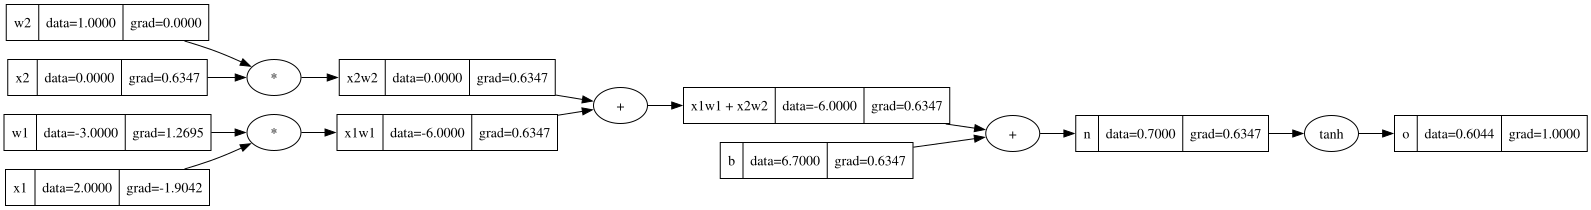

In [18]:
# inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias
b = Value(6.7, label='b')

# network
x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

# Now let's call _backward instead of manual gradient calculation (the output supposed to be same)
o.grad = 1.0 # initialize the base case
o._backward()
n._backward()
x1w1x2w2._backward()
b._backward()
x1w1._backward()
x2w2._backward()
x1._backward()
w1._backward()
x2._backward()
w2._backward()

draw_dot(o)

[Value(data=0.6043677771171636, label=o), Value(data=0.7000000000000002, label=n), Value(data=-6.0, label=x1w1 + x2w2), Value(data=6.7, label=b), Value(data=0.0, label=x2w2), Value(data=-6.0, label=x1w1), Value(data=0.0, label=x2), Value(data=1.0, label=w2), Value(data=2.0, label=x1), Value(data=-3.0, label=w1)]


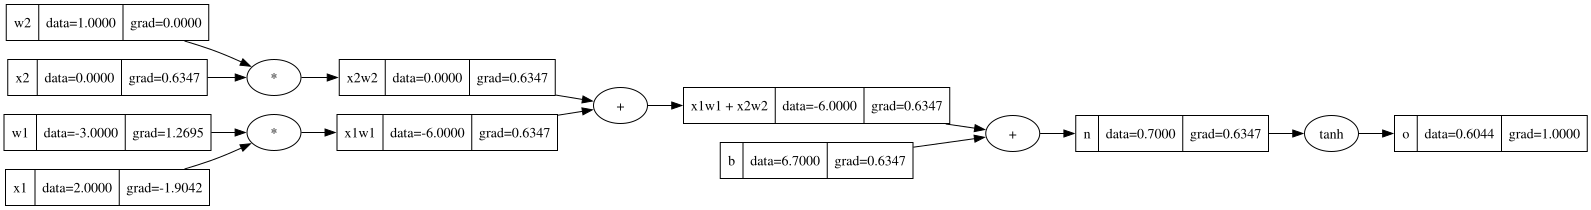

In [19]:
# In order to get the correct grad values, _backward should be called after its output _backward called
# So basically _backward should be called in a topological order. Starting from root node and processing through the leafs
# We get the topological order by using breadth-first-search (BFS)

from collections import deque

def build_topo(root):
    topo = []
    visited = set([root])
    queue = deque([root])
    while queue:
        v = queue.popleft()
        topo.append(v)
        for u in v._children:
            if u not in visited:
                visited.add(u)
                queue.append(u)
    return topo
    
topo = build_topo(o)
print(topo)

for v in topo:
    v._backward()
draw_dot(o)

In [ ]:
# Put the backward functionality into the class

from collections import deque

class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._children = set(_children)
        self._backward = lambda: None
        self._op = _op
        self.label = label
    
    def __repr__(self):
        return f"Value(data={self.data}, label={self.label})"
    
    def __add__(self, other):
        out = Value(self.data + other.data,  (self, other), '+')

        def _backward():
            self.grad = 1.0 * out.grad
            other.grad = 1.0 * out.grad

        out._backward = _backward
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')        

        def _backward():
            self.grad = other.data * out.grad
            other.grad = self.data * out.grad

        out._backward = _backward
        return out
    
    def tanh(self):
        # tanh = e**(2x) - 1 / e**(2x) + 1
        t = (math.exp(2*self.data) - 1) / (math.exp(2*self.data) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            # derivative of tanh is 1 - tanh(n)**2
            self.grad = 1 - t**2 * out.grad

        out._backward = _backward
        return out

    def backward(self):
        def build_topo(root):
            topo = []
            visited = set([root])
            queue = deque([root])
            while queue:
                v = queue.popleft()
                topo.append(v)
                for u in v._children:
                    if u not in visited:
                        visited.add(u)
                        queue.append(u)
            return topo

        # Make the topological order from root to leaf nodes    
        topo = build_topo(self)
        # Set the base case
        self.grad = 1.0       
        # Call backward
        for v in topo:
            v._backward()


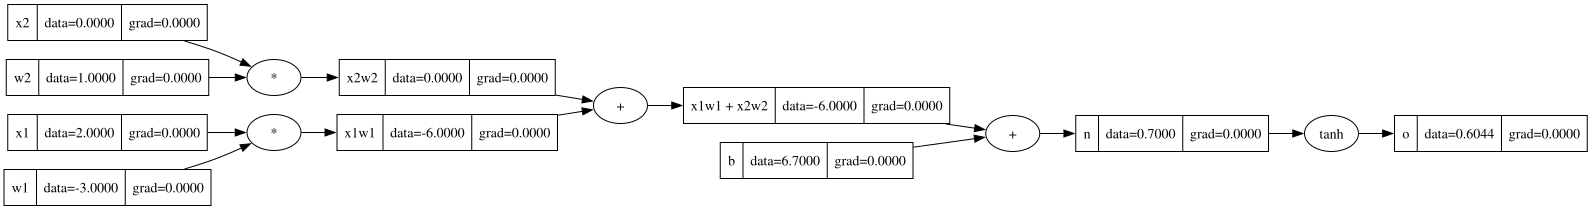

In [25]:
# inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias
b = Value(6.7, label='b')

# network
x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

draw_dot(o)

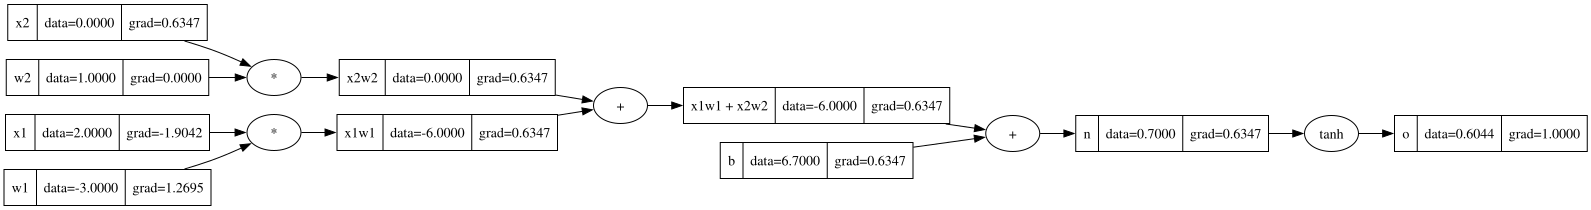

In [26]:
# call backward
o.backward()
draw_dot(o)

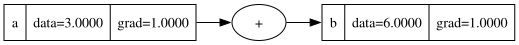

In [28]:
# The current implementation works only when we use all the variables once
# But if we use it like the one below, gradient calculation breaks up
a = Value(3.0, label='a')
b = a + a; b.label = 'b'
b.backward() 
draw_dot(b)

# b = 2*a
# db/da = 2

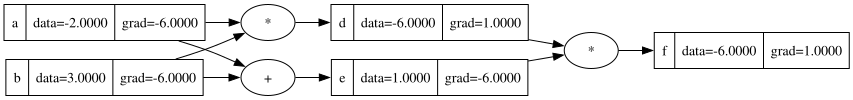

In [ ]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
# a effects d and e, and its gradient value is overwitten by them
# so instead of assigning the grad values, we should 'accumulate' them
d = a * b; d.label = 'd'
e = a + b; e.label = 'e'
f = d * e; f.label = 'f'

f.backward()
draw_dot(f)

In [50]:
# Support gradient accumulation

from collections import deque

class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._children = set(_children)
        self._backward = lambda: None
        self._op = _op
        self.label = label
    
    def __repr__(self):
        return f"Value(data={self.data}, label={self.label})"
    
    def __add__(self, other):
        out = Value(self.data + other.data,  (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad

        out._backward = _backward
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')        

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out
    
    def tanh(self):
        # tanh = e**(2x) - 1 / e**(2x) + 1
        t = (math.exp(2*self.data) - 1) / (math.exp(2*self.data) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            # derivative of tanh is 1 - tanh(n)**2
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward
        return out

    def backward(self):
        def build_topo(root):
            topo = []
            visited = set([root])
            queue = deque([root])
            while queue:
                v = queue.popleft()
                topo.append(v)
                for u in v._children:
                    if u not in visited:
                        visited.add(u)
                        queue.append(u)
            return topo

        # Make the topological order from root to leaf nodes    
        topo = build_topo(self)
        # Set the base case
        self.grad = 1.0       
        # Call backward
        for v in topo:
            v._backward()


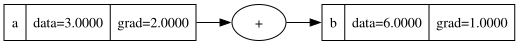

In [ ]:
# The current implementation works only when we use all the variables once
# But if we use it like the one below, gradient calculation breaks up
a = Value(3.0, label='a')
b = a + a; b.label = 'b'
b.backward() 
draw_dot(b)

# b = 2*a
# db/da = 2

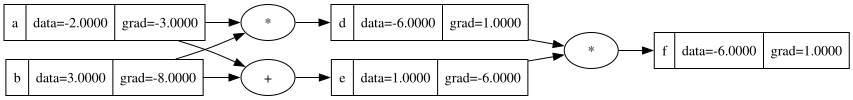

In [ ]:
# Multivarite Chain Rule:
# df/db = df/de * de/db + df/dd * dd/db
# df/db = -6.0 * 1.0 + 1.0 * 1.0 = 5.0 


a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b; d.label = 'd'
e = a + b; e.label = 'e'
f = d * e; f.label = 'f'

f.backward()
draw_dot(f)

[Value(data=-8.0, label=d), Value(data=-2.0, label=a), Value(data=-6.0, label=c), Value(data=3.0, label=b)]


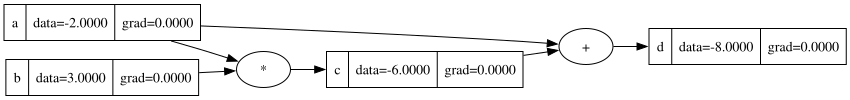

In [ ]:
# I made a mistake. Topological sorting is done via DFS not BFS

from collections import deque

def build_topo(root):
    topo = []
    visited = set([root])
    queue = deque([root])
    while queue:
        v = queue.popleft()
        topo.append(v)
        for u in v._children:
            if u not in visited:
                visited.add(u)
                queue.append(u)
    return topo

# See the example
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
c = a * b; c.label = 'c'
d = c + a; d.label = 'd'

topo = build_topo(d)
print(topo)
draw_dot(d)

In [56]:
# As you can see above, a cannot came before c in topological order, so the correct algorithm supposed to be BFS
topo = []
visited = set()

def build_topo(v):
    if v not in visited:
        visited.add(v)
        for u in v._children:
            build_topo(u)
        # After processing all the children, add the current node into the list
        topo.append(v)

# The topological order is the reversed of topo
build_topo(d)
print(topo[::-1])

[Value(data=-8.0, label=d), Value(data=-6.0, label=c), Value(data=3.0, label=b), Value(data=-2.0, label=a)]


In [59]:
# Update topological sort

class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._children = set(_children)
        self._backward = lambda: None
        self._op = _op
        self.label = label
    
    def __repr__(self):
        return f"Value(data={self.data}, label={self.label})"
    
    def __add__(self, other):
        out = Value(self.data + other.data,  (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad

        out._backward = _backward
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')        

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out
    
    def tanh(self):
        # tanh = e**(2x) - 1 / e**(2x) + 1
        t = (math.exp(2*self.data) - 1) / (math.exp(2*self.data) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            # derivative of tanh is 1 - tanh(n)**2
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()

        def build_topo(v):
            # Build topological sort using DFS post-order traversal
            if v not in visited:
                visited.add(v)
                for child in v._children:
                    build_topo(child)
            topo.add(v)
        
        # Make the topological order from root to leaf nodes    
        build_topo(self)
        # Set the base case
        self.grad = 1.0       
        # Call backward
        for v in topo[::-1]:
            v._backward()